# Voting Regressor

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

In [19]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)

X = boston.data.astype(float)
y = boston.target.astype(float)

In [20]:
print('X:' ,X.shape)
print('Y: ',y.shape)

X: (506, 13)
Y:  (506,)


In [21]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
svr = SVR()

In [22]:
estimators = [('lr', lr), ('dt', dt), ('svr', svr)]

In [23]:
for estimator in estimators:
    scores = cross_val_score(estimator[1], X,y,scoring='r2', cv=10)
    print(estimator[0], np.round(np.mean(scores),2))

lr 0.2
dt -0.2
svr -0.41


In [24]:
from sklearn.ensemble import VotingRegressor

In [25]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr, X,y,scoring='r2', cv=10)
print('VR: ', np.round(np.mean(scores),2))

VR:  0.45


In [26]:
results = []

for i in range(1, 4):
    for j in range(1, 4):
        for k in range(1, 4):
            vr = VotingRegressor(
                estimators=estimators,
                weights=[i, j, k]
            )

            scores = cross_val_score(
                vr, X, y,
                cv=10,
                scoring='r2'
            )

            mean_score = np.round(np.mean(scores), 2)

            results.append((f"{i},{j},{k}", mean_score))

            print(
                "for i={}, j={}, k={}".format(i, j, k),
                mean_score
            )

for i=1, j=1, k=1 0.43
for i=1, j=1, k=2 0.35
for i=1, j=1, k=3 0.24
for i=1, j=2, k=1 0.4
for i=1, j=2, k=2 0.35
for i=1, j=2, k=3 0.35
for i=1, j=3, k=1 0.36
for i=1, j=3, k=2 0.39
for i=1, j=3, k=3 0.36
for i=2, j=1, k=1 0.46
for i=2, j=1, k=2 0.4
for i=2, j=1, k=3 0.33
for i=2, j=2, k=1 0.47
for i=2, j=2, k=2 0.44
for i=2, j=2, k=3 0.35
for i=2, j=3, k=1 0.39
for i=2, j=3, k=2 0.44
for i=2, j=3, k=3 0.37
for i=3, j=1, k=1 0.44
for i=3, j=1, k=2 0.43
for i=3, j=1, k=3 0.39
for i=3, j=2, k=1 0.45
for i=3, j=2, k=2 0.4
for i=3, j=2, k=3 0.43
for i=3, j=3, k=1 0.44
for i=3, j=3, k=2 0.46
for i=3, j=3, k=3 0.44


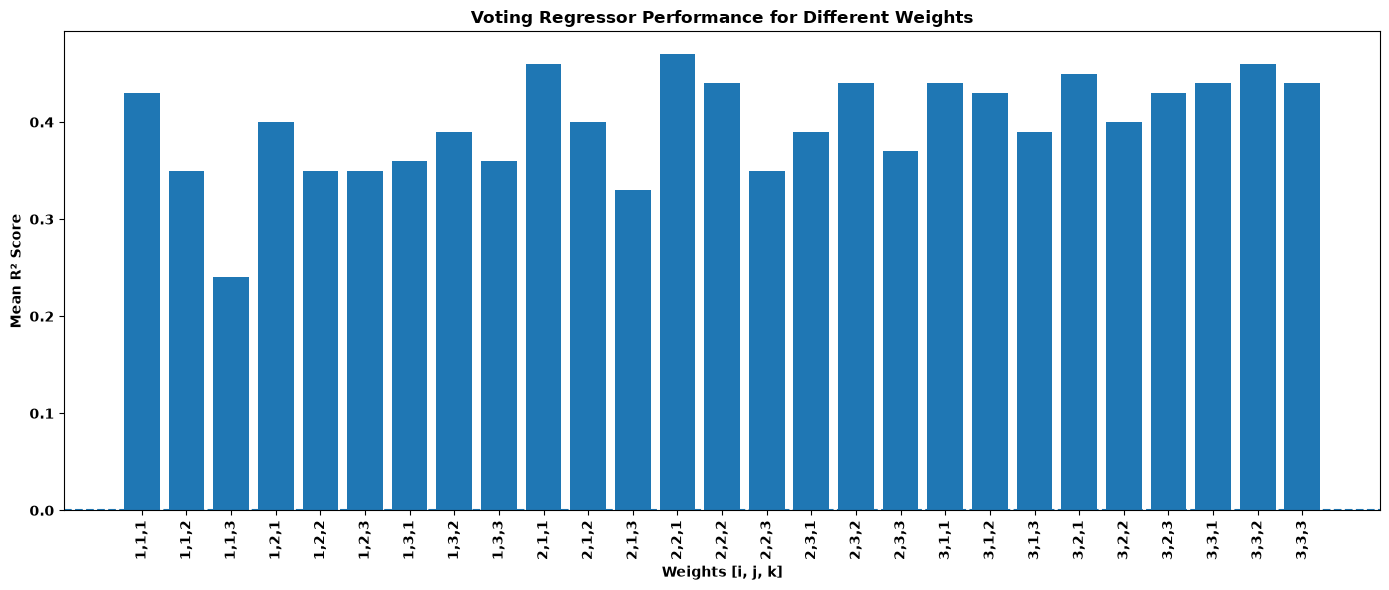

In [27]:
# Separate labels and scores
labels = [x[0] for x in results]
scores = [x[1] for x in results]

plt.figure(figsize=(14, 6))

plt.bar(labels, scores)

plt.axhline(0, linestyle='--')

plt.xlabel("Weights [i, j, k]")
plt.ylabel("Mean R² Score")
plt.title("Voting Regressor Performance for Different Weights")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [28]:
# using the same algorithm 

dt1 = DecisionTreeRegressor(max_depth=1)
dt2 = DecisionTreeRegressor(max_depth=3)
dt3 = DecisionTreeRegressor(max_depth=5)
dt4 = DecisionTreeRegressor(max_depth=7)
dt5 = DecisionTreeRegressor(max_depth=None)

In [29]:
estimators = [('dt1',dt1), ('dt2',dt2), ('dt3',dt3), ('dt4',dt4), ('dt5',dt5)]

In [30]:
for estimator in estimators:
    scores = cross_val_score(estimator[1], X,y,scoring='r2', cv=10)
    print(estimator[0], np.round(np.mean(scores),2)) 

dt1 -0.85
dt2 -0.21
dt3 0.06
dt4 0.11
dt5 -0.18


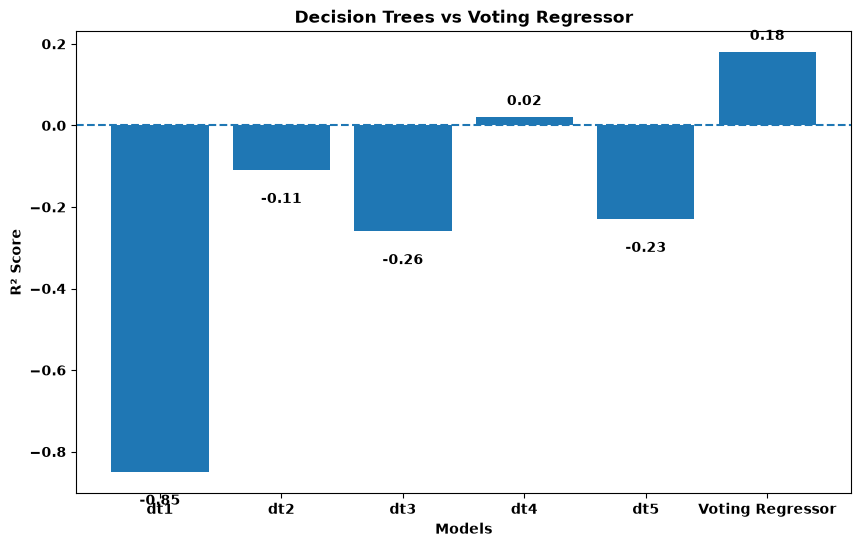

In [31]:

models = ['dt1', 'dt2', 'dt3', 'dt4', 'dt5', 'Voting Regressor']
scores = [-0.85, -0.11, -0.26, 0.02, -0.23, 0.18]

plt.figure(figsize=(10, 6))

bars = plt.bar(models, scores)

# Add values on top of bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.03 if score >= 0 else score - 0.08,
        str(score),
        ha='center'
    )

plt.axhline(y=0, linestyle='--')

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Decision Trees vs Voting Regressor")

plt.show()

In [32]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr, X,y,scoring='r2', cv=10)
print('VR: ', np.round(np.mean(scores),2))

VR:  0.19
